# RQ3: Model Comparison (ML Dataset)

**Research question:** How do traditional machine learning models compare with neural network models in predicting short-form video trend labels?

## 1. Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TARGET = "trend_label"

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## 2. Load ML Processed Data

The inputs are already numeric because preprocessing handled categorical encoding. RQ3 uses the full encoded feature matrix for every model so that the comparison isolates model choice rather than feature-group choice.

In [ ]:
train = pd.read_csv("../../data/processed_ml/train.csv")
validation = pd.read_csv("../../data/processed_ml/validation.csv")
test = pd.read_csv("../../data/processed_ml/test.csv")

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]

X_val = validation.drop(columns=TARGET)
y_val = validation[TARGET]

X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Non-numeric columns:", X_train.select_dtypes(exclude=["number"]).columns.tolist())

display(y_train.value_counts(normalize=True).sort_index())

Train: (35000, 72) (35000,)
Validation: (7500, 72) (7500,)
Test: (7500, 72) (7500,)
Non-numeric columns: []


trend_label
declining    0.101971
rising       0.250000
seasonal     0.094114
stable       0.553914
Name: proportion, dtype: float64

## 3. Model Set and Hyperparameter Tuning

Feature groups are not varied in this notebook. RQ2 already evaluates feature-group effectiveness, while RQ3 focuses on whether model family changes predictive performance.

The model set covers a high-bias to lower-bias range: a majority baseline, linear models, a single decision tree, an ensemble tree model, and an MLP neural network. Each model has at least one hyperparameter tuned using validation macro F1.


In [3]:
def format_params(params):
    return ", ".join(f"{key}={value}" for key, value in params.items())


model_configs = {
    "Dummy Majority": {
        "type": "baseline",
        "bias_variance_position": "highest bias / lowest variance reference model",
        "tuned_hyperparameters": "strategy",
        "param_grid": {
            "strategy": ["most_frequent", "prior"],
        },
        "build_model": lambda params: DummyClassifier(
            strategy=params["strategy"],
            random_state=RANDOM_STATE,
        ),
    },
    "Logistic Regression": {
        "type": "traditional",
        "bias_variance_position": "high-bias linear classifier",
        "tuned_hyperparameters": "C",
        "param_grid": {
            "C": [0.1, 1.0, 10.0],
        },
        "build_model": lambda params: make_pipeline(
            StandardScaler(),
            LogisticRegression(
                C=params["C"],
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    },
    "Linear SVM": {
        "type": "traditional",
        "bias_variance_position": "regularised linear margin classifier",
        "tuned_hyperparameters": "C",
        "param_grid": {
            "C": [0.1, 1.0, 10.0],
        },
        "build_model": lambda params: make_pipeline(
            StandardScaler(),
            LinearSVC(
                C=params["C"],
                class_weight="balanced",
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    },
    "Decision Tree": {
        "type": "traditional",
        "bias_variance_position": "low-bias / high-variance single tree",
        "tuned_hyperparameters": "max_depth, min_samples_leaf",
        "param_grid": {
            "max_depth": [6, 12],
            "min_samples_leaf": [5, 20],
        },
        "build_model": lambda params: DecisionTreeClassifier(
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    },
    "Random Forest": {
        "type": "traditional",
        "bias_variance_position": "lower-variance ensemble of decision trees",
        "tuned_hyperparameters": "n_estimators, min_samples_leaf",
        "param_grid": {
            "n_estimators": [80, 120],
            "min_samples_leaf": [5, 10],
        },
        "build_model": lambda params: RandomForestClassifier(
            n_estimators=params["n_estimators"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced_subsample",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
    },
    "MLP Neural Network": {
        "type": "neural_network",
        "bias_variance_position": "flexible non-linear neural model",
        "tuned_hyperparameters": "hidden_layer_sizes, alpha",
        "param_grid": {
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [0.0001, 0.001],
        },
        "build_model": lambda params: make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=params["hidden_layer_sizes"],
                alpha=params["alpha"],
                max_iter=80,
                random_state=RANDOM_STATE,
            ),
        ),
    },
}

hyperparameter_plan = pd.DataFrame([
    {
        "model": model_name,
        "type": config["type"],
        "bias_variance_position": config["bias_variance_position"],
        "tuned_hyperparameters": config["tuned_hyperparameters"],
        "candidate_values": config["param_grid"],
    }
    for model_name, config in model_configs.items()
])

display(hyperparameter_plan)


,model,type,bias_variance_position,tuned_hyperparameters,candidate_values
0,Dummy Majority,baseline,highest bias / lowest variance reference model,strategy,"{'strategy': ['most_frequent', 'prior']}"
1,Logistic Regression,traditional,high-bias linear classifier,C,"{'C': [0.1, 1.0, 10.0]}"
2,Linear SVM,traditional,regularised linear margin classifier,C,"{'C': [0.1, 1.0, 10.0]}"
3,Decision Tree,traditional,low-bias / high-variance single tree,"max_depth, min_samples_leaf","{'max_depth': [6, 12], 'min_samples_leaf': [5,..."
4,Random Forest,traditional,lower-variance ensemble of decision trees,"n_estimators, min_samples_leaf","{'n_estimators': [80, 120], 'min_samples_leaf'..."
5,MLP Neural Network,neural_network,flexible non-linear neural model,"hidden_layer_sizes, alpha","{'hidden_layer_sizes': [(32,), (64, 32)], 'alp..."


## 4. Validation Comparison

All models use the same stratified train/validation/test split created in preprocessing. This is suitable here because the dataset is large enough for a hold-out validation set, and stratification keeps the four trend classes similarly balanced across splits.

Hyperparameters are selected using validation macro F1 because this is a multi-class task and each class should contribute equally to model selection. The test set is kept separate until after tuning.


In [4]:
tuning_rows = []
validation_rows = []
trained_models = {}
chosen_params = {}

for model_name, config in model_configs.items():
    best = None

    for params in ParameterGrid(config["param_grid"]):
        model = config["build_model"](params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        accuracy = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro")

        tuning_rows.append({
            "model": model_name,
            "type": config["type"],
            "hyperparameters": format_params(params),
            "accuracy": accuracy,
            "macro_f1": macro_f1,
        })

        if best is None or macro_f1 > best["macro_f1"]:
            best = {
                "params": params,
                "model": model,
                "accuracy": accuracy,
                "macro_f1": macro_f1,
            }

    trained_models[model_name] = best["model"]
    chosen_params[model_name] = best["params"]

    validation_rows.append({
        "model": model_name,
        "type": config["type"],
        "bias_variance_position": config["bias_variance_position"],
        "tuned_hyperparameters": config["tuned_hyperparameters"],
        "chosen_hyperparameters": format_params(best["params"]),
        "accuracy": best["accuracy"],
        "macro_f1": best["macro_f1"],
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["model", "macro_f1"],
    ascending=[True, False],
).reset_index(drop=True)

validation_results = pd.DataFrame(validation_rows).sort_values(
    "macro_f1",
    ascending=False,
).reset_index(drop=True)

display(validation_results.round(4))
display(tuning_results.round(4))


,model,type,bias_variance_position,tuned_hyperparameters,chosen_hyperparameters,accuracy,macro_f1
0,Random Forest,traditional,lower-variance ensemble of decision trees,"n_estimators, min_samples_leaf","min_samples_leaf=5, n_estimators=80",0.8048,0.7784
1,MLP Neural Network,neural_network,flexible non-linear neural model,"hidden_layer_sizes, alpha","alpha=0.0001, hidden_layer_sizes=(32,)",0.8015,0.7613
2,Decision Tree,traditional,low-bias / high-variance single tree,"max_depth, min_samples_leaf","max_depth=6, min_samples_leaf=5",0.7777,0.7550
3,Linear SVM,traditional,regularised linear margin classifier,C,C=0.1,0.7721,0.7307
4,Logistic Regression,traditional,high-bias linear classifier,C,C=10.0,0.7519,0.7287
5,Dummy Majority,baseline,highest bias / lowest variance reference model,strategy,strategy=most_frequent,0.5540,0.1782


,model,type,hyperparameters,accuracy,macro_f1
0,Decision Tree,traditional,"max_depth=6, min_samples_leaf=5",0.7777,0.7550
1,Decision Tree,traditional,"max_depth=6, min_samples_leaf=20",0.7768,0.7540
2,Decision Tree,traditional,"max_depth=12, min_samples_leaf=20",0.7525,0.7230
3,Decision Tree,traditional,"max_depth=12, min_samples_leaf=5",0.7425,0.7121
4,Dummy Majority,baseline,strategy=most_frequent,0.5540,0.1782
5,Dummy Majority,baseline,strategy=prior,0.5540,0.1782
6,Linear SVM,traditional,C=0.1,0.7721,0.7307
7,Linear SVM,traditional,C=1.0,0.7693,0.7303
8,Linear SVM,traditional,C=10.0,0.7684,0.7293
9,Logistic Regression,traditional,C=10.0,0.7519,0.7287


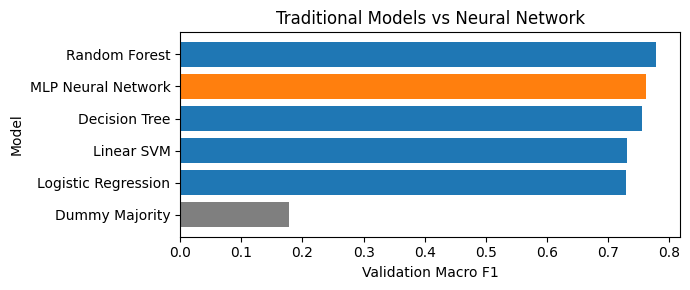

In [5]:
plot_data = validation_results.sort_values("macro_f1")
colors = plot_data["type"].map({
    "baseline": "tab:gray",
    "traditional": "tab:blue",
    "neural_network": "tab:orange",
})

plt.figure(figsize=(7, 3))
plt.barh(plot_data["model"], plot_data["macro_f1"], color=colors)
plt.xlabel("Validation Macro F1")
plt.ylabel("Model")
plt.title("Traditional Models vs Neural Network")
plt.tight_layout()
plt.show()

## 5. Final Test Evaluation

After validation tuning, the chosen version of every model is evaluated on the test set. Detailed classification reports and confusion matrices are shown for the majority baseline, the best traditional validation model, and the MLP neural network.



=== Random Forest ===
              precision    recall  f1-score   support

   declining      0.656     0.869     0.748       765
      rising      0.754     0.769     0.761      1875
    seasonal      0.827     0.711     0.765       706
      stable      0.875     0.836     0.855      4154

    accuracy                          0.811      7500
   macro avg      0.778     0.796     0.782      7500
weighted avg      0.818     0.811     0.812      7500



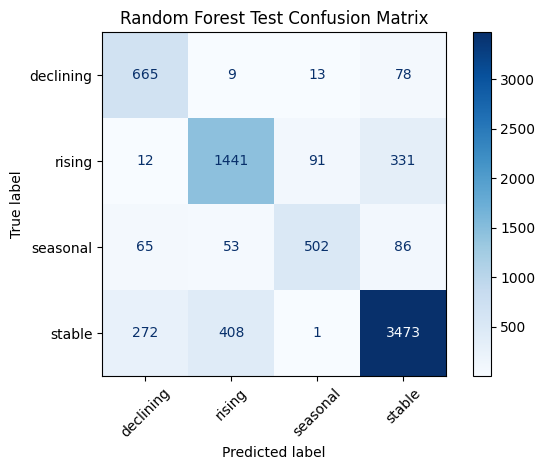


=== MLP Neural Network ===
              precision    recall  f1-score   support

   declining      0.740     0.699     0.719       765
      rising      0.798     0.716     0.755      1875
    seasonal      0.802     0.710     0.753       706
      stable      0.838     0.901     0.868      4154

    accuracy                          0.816      7500
   macro avg      0.794     0.757     0.774      7500
weighted avg      0.814     0.816     0.814      7500



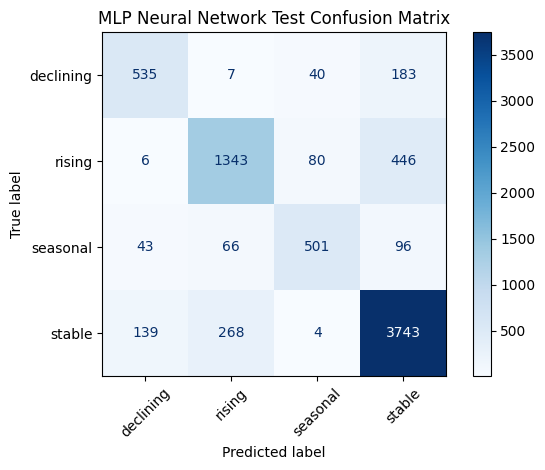


=== Dummy Majority ===
              precision    recall  f1-score   support

   declining      0.000     0.000     0.000       765
      rising      0.000     0.000     0.000      1875
    seasonal      0.000     0.000     0.000       706
      stable      0.554     1.000     0.713      4154

    accuracy                          0.554      7500
   macro avg      0.138     0.250     0.178      7500
weighted avg      0.307     0.554     0.395      7500



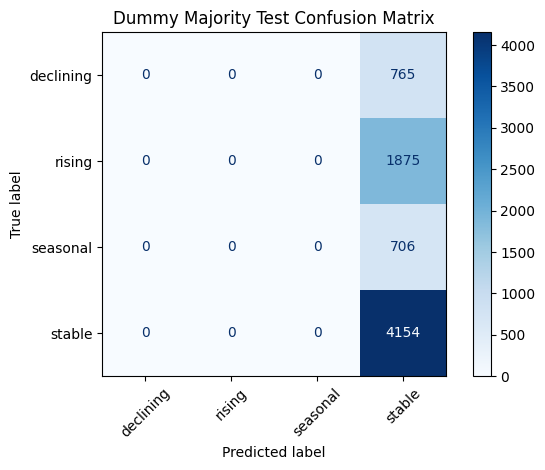

,model,type,chosen_hyperparameters,accuracy,macro_f1
0,Random Forest,traditional,"min_samples_leaf=5, n_estimators=80",0.8108,0.7822
1,MLP Neural Network,neural_network,"alpha=0.0001, hidden_layer_sizes=(32,)",0.8163,0.7737
2,Decision Tree,traditional,"max_depth=6, min_samples_leaf=5",0.7877,0.7628
3,Linear SVM,traditional,C=0.1,0.7792,0.7335
4,Logistic Regression,traditional,C=10.0,0.7561,0.7300
5,Dummy Majority,baseline,strategy=most_frequent,0.5539,0.1782


In [6]:
best_traditional = validation_results[validation_results["type"] == "traditional"].iloc[0]["model"]
final_model_names = validation_results["model"].tolist()
detailed_model_names = ["Dummy Majority", best_traditional, "MLP Neural Network"]

final_rows = []
for model_name in final_model_names:
    model = trained_models[model_name]
    y_pred = model.predict(X_test)

    final_rows.append({
        "model": model_name,
        "type": model_configs[model_name]["type"],
        "chosen_hyperparameters": format_params(chosen_params[model_name]),
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

    if model_name in detailed_model_names:
        print()
        print("===", model_name, "===")
        print(classification_report(y_test, y_pred, digits=3, zero_division=0))

        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            xticks_rotation=45,
            cmap="Blues",
        )
        plt.title(f"{model_name} Test Confusion Matrix")
        plt.tight_layout()
        plt.show()

final_results = pd.DataFrame(final_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(final_results.round(4))


## 6. Summary

The ML-preprocessed dataset produces a much clearer model comparison than the original CSV. On the original processed data, all models were close to chance: the best test macro F1 was the MLP at about 0.256, followed by Linear SVM and Random Forest around 0.249. This suggested that the original feature set had weak predictive signal. On the ML dataset, every non-baseline model improves substantially, with test macro F1 scores from about 0.730 to 0.782.

The best validation model is Random Forest with `n_estimators=80` and `min_samples_leaf=5`, reaching 0.778 validation macro F1. On the held-out test set it remains the best by macro F1, reaching 0.811 accuracy and 0.782 macro F1. The MLP neural network has slightly higher test accuracy at 0.816, but its macro F1 is lower at 0.774, meaning it is not the strongest model when each class is weighted equally.

The final ML test ranking by macro F1 is: Random Forest at 0.782, MLP Neural Network at 0.774, Decision Tree at 0.763, Linear SVM at 0.734, Logistic Regression at 0.730, and Dummy Majority at 0.178. The gap between the baseline and all real models is large, so the high accuracy is not just caused by the majority `stable` class. The classification reports also show that Random Forest and MLP both make useful predictions for the minority `declining` and `seasonal` classes.

Overall answer to RQ3: traditional models and neural models both benefit strongly from the ML-engineered feature set. The MLP is competitive and gives the highest test accuracy, but Random Forest is the best overall choice because it has the highest validation and test macro F1. Compared with the original CSV, the main improvement comes from the ML features rather than from switching to a neural network.